# Assignment 1
IN6227 Data Mining | Roshani Ayu Pranasti | G2504973A

## Import Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

## Dataset Definition
Cencus Income Dataset splits into 2 types:
1. **Train Dataset**: `Census Income Data Set/adult.data`
2. **Test Dataset**: `Census Income Data Set/adult.test`

## Data Preparation

### Prepare Train Dataset

#### 1. Load Train Dataset

In [2]:
# Load dataset
cencus_income_train_dataset = pd.read_csv("Census Income Data Set/adult.data")
display(cencus_income_train_dataset)

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32556,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32557,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32558,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#### 2. Define Column Names

It can be seen that train dataset doesn't have a header row with column names, so I define them in a list based on column names defined in `adult.names`. This will make the data much easier to work with.

In [3]:
# Define the column names for the dataset
column_names = [
    "age", 
    "workclass", 
    "fnlwgt", 
    "education", 
    "education-num", 
    "marital-status", 
    "occupation", 
    "relationship", 
    "race", 
    "sex", 
    "capital-gain", 
    "capital-loss", 
    "hours-per-week",
    "native-country", 
    "income"
]

# Load dataset again with parameters:
# header=None: there's no header row in the file.
# names=column_names: assigns list of column names to the DataFrame.
# na_values="?": recognizes the string "?" as a missing or unknown value and represent it as NaN (Not a Number) in the DataFrame.
# skipinitialspace=True: saves from potential errors caused by inconsistent whitespace.
cencus_income_train_dataset = pd.read_csv("Census Income Data Set/adult.data", header=None, names=column_names, na_values="?", skipinitialspace=True)
display(cencus_income_train_dataset)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
print("Number of attributes in dataset:", cencus_income_train_dataset.shape[1])
print("Number of data in dataset:", cencus_income_train_dataset.shape[0], "\n")
cencus_income_train_dataset.info()

Number of attributes in dataset: 15
Number of data in dataset: 32561 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#### 3. Check for Unknown or Missing Values  

In [5]:
print("Number of unknown or missing values in dataset:")
cencus_income_train_dataset.isnull().sum()

Number of unknown or missing values in dataset:


age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

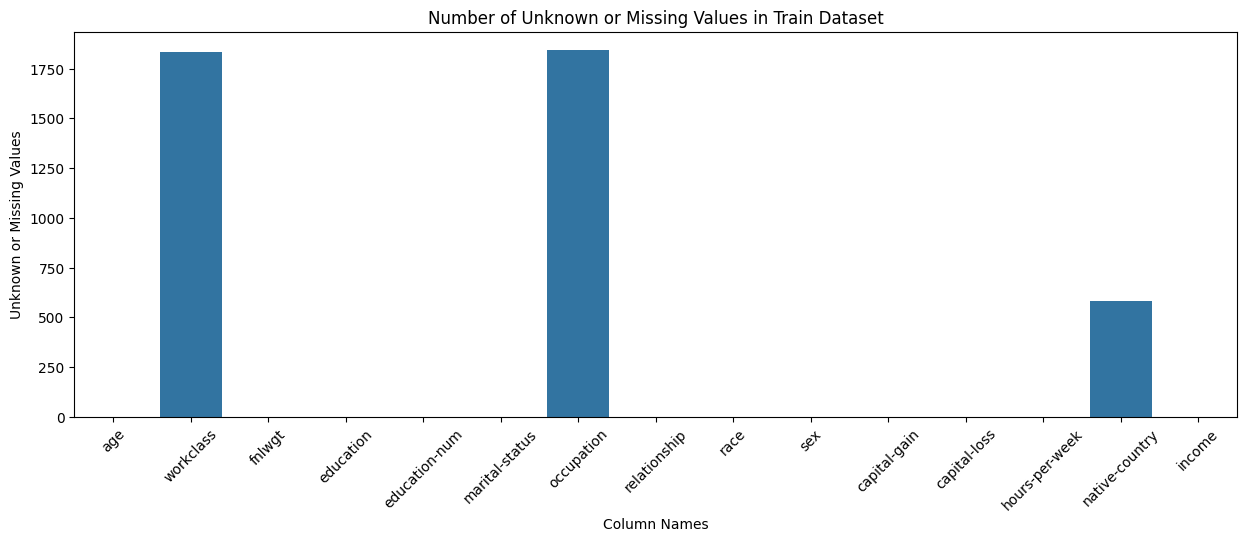

In [6]:
# Create the visualization of number of unknown or missing Values in dataset
plt.figure(figsize=(15, 5))
sns.barplot(x=cencus_income_train_dataset.isnull().sum().index, y=cencus_income_train_dataset.isnull().sum())
plt.title("Number of Unknown or Missing Values in Train Dataset")
plt.xlabel("Column Names")
plt.ylabel("Unknown or Missing Values")
plt.tick_params("x", rotation=45)

#### 4. Handle Unknown or Missing Values

In [7]:
# Remove rows with any missing values
cleaned_cencus_income_train_dataset = cencus_income_train_dataset.dropna()
display(cleaned_cencus_income_train_dataset)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


### Prepare Test Dataset

#### 1. Load Test Dataset

In [8]:
# Load dataset
cencus_income_test_dataset = pd.read_csv("Census Income Data Set/adult.test")
display(cencus_income_test_dataset)

,,,,,,,,,,,,,,|1x3 Cross validator
25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K.
38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


#### 2. Define Column Names

It can be seen that test dataset has an irrelevant header row name, so I define them in a list based on column names defined in `adult.names`. This will make the data much easier to work with.

In [9]:
# Define the column names for the dataset
column_names = [
    "age", 
    "workclass", 
    "fnlwgt", 
    "education", 
    "education-num", 
    "marital-status", 
    "occupation", 
    "relationship", 
    "race", 
    "sex", 
    "capital-gain", 
    "capital-loss", 
    "hours-per-week",
    "native-country", 
    "income"
]

# Load dataset again with parameters:
# header=None: there's no header row in the file.
# names=column_names: assigns list of column names to the DataFrame.
# na_values="?": recognizes the string "?" as a missing or unknown value and represent it as NaN (Not a Number) in the DataFrame.
# skiprows=1: removes the first unwanted header.
# skipinitialspace=True: saves from potential errors caused by inconsistent whitespace.
cencus_income_test_dataset = pd.read_csv("Census Income Data Set/adult.test", header=None, names=column_names, na_values="?", skiprows=1, skipinitialspace=True)
display(cencus_income_test_dataset)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
16277,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
16278,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
16279,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [10]:
print("Number of attributes in dataset:", cencus_income_test_dataset.shape[1])
print("Number of data in dataset:", cencus_income_test_dataset.shape[0], "\n")
cencus_income_test_dataset.info()

Number of attributes in dataset: 15
Number of data in dataset: 16281 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16281 non-null  int64 
 1   workclass       15318 non-null  object
 2   fnlwgt          16281 non-null  int64 
 3   education       16281 non-null  object
 4   education-num   16281 non-null  int64 
 5   marital-status  16281 non-null  object
 6   occupation      15315 non-null  object
 7   relationship    16281 non-null  object
 8   race            16281 non-null  object
 9   sex             16281 non-null  object
 10  capital-gain    16281 non-null  int64 
 11  capital-loss    16281 non-null  int64 
 12  hours-per-week  16281 non-null  int64 
 13  native-country  16007 non-null  object
 14  income          16281 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.9+ MB


#### 3. Check for Unknown or Missing Values  

In [11]:
print("Number of unknown or missing values in dataset:")
cencus_income_test_dataset.isnull().sum()

Number of unknown or missing values in dataset:


age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

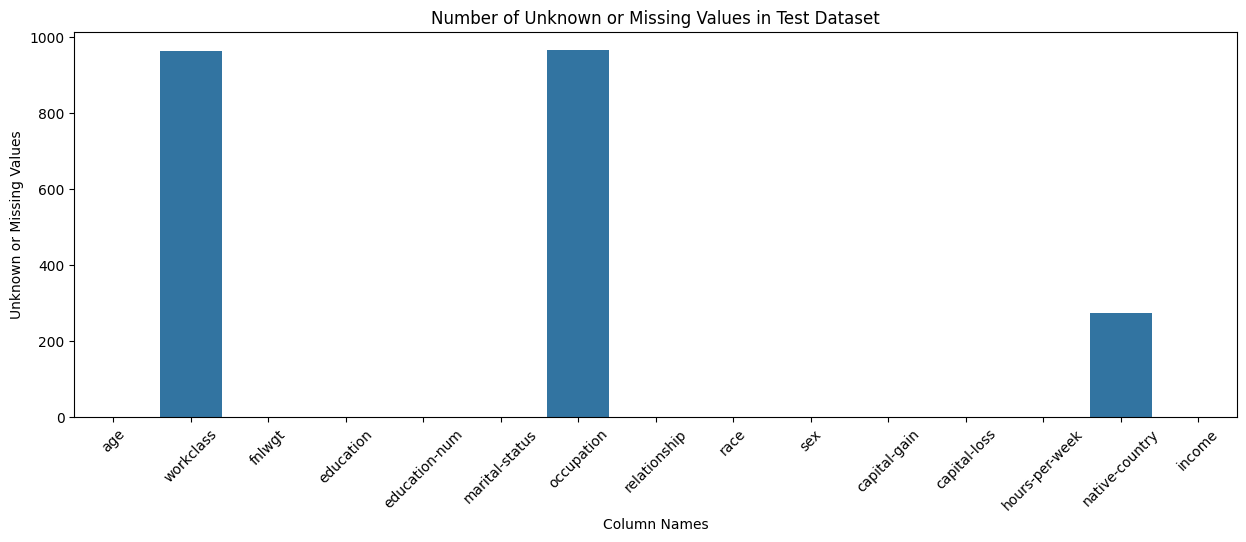

In [12]:
# Create the visualization of number of unknown or missing Values in dataset
plt.figure(figsize=(15, 5))
sns.barplot(x=cencus_income_test_dataset.isnull().sum().index, y=cencus_income_test_dataset.isnull().sum())
plt.title("Number of Unknown or Missing Values in Test Dataset")
plt.xlabel("Column Names")
plt.ylabel("Unknown or Missing Values")
plt.tick_params("x", rotation=45)

#### 4. Handle Unknown or Missing Values

In [13]:
# Remove rows with any missing values
cleaned_cencus_income_test_dataset = cencus_income_test_dataset.dropna()
display(cleaned_cencus_income_test_dataset)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K.
16276,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
16278,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
16279,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


#### 5. Do Additional Preprocessing

It can be seen that all the data in the `income` column consists of a period character or `"."`. I will remove it to make the data much easier to work with.

In [14]:
# Clean the income column in dataset
cleaned_cencus_income_test_dataset["income"] = cleaned_cencus_income_test_dataset["income"].str.replace(".", "", regex=False)
display(cleaned_cencus_income_test_dataset)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
16276,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
16278,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
16279,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


### Feature Engineering

Models often require numerical input. It is known that the train and test data have several categorical columns, like `workclass`, `occupation`, etc. I will convert these into a numerical format.

#### 1. One-Hot Encoding
Creates new binary (0 or 1) columns for each category within a feature to represent categorical data without implying an ordinal relationship.

In [15]:
# Separate features (X) and target (y)
X_train_data = cleaned_cencus_income_train_dataset.drop("income", axis=1)
y_train_data = cleaned_cencus_income_train_dataset["income"]
X_test_data = cleaned_cencus_income_test_dataset.drop("income", axis=1)
y_test_data = cleaned_cencus_income_test_dataset["income"]

# One-hot encode categorical features
X_train_data = pd.get_dummies(X_train_data, drop_first=True)
X_test_data = pd.get_dummies(X_test_data, drop_first=True)

print("Train data:")
display(X_train_data)
print("Test data:")
display(X_test_data)

Train data:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,0,38,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
32557,40,154374,9,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
32558,58,151910,9,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
32559,22,201490,9,0,0,20,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


Test data:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,198693,6,0,0,30,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,33,245211,13,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
16276,39,215419,13,0,0,36,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
16278,38,374983,13,0,0,50,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
16279,44,83891,13,5455,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


#### 2. Column Alignment
After getting the result of one-hot encoding, it can be seen that the train and test data have a different number of columns.


In [16]:
print("Number of features in train data:", X_train_data.shape[1])
print("Number of features in test data:", X_test_data.shape[1])

Number of features in train data: 96
Number of features in test data: 95


This means the train data has a category that the test data doesn't. Hence, I align them to ensure they have the exact same columns.

In [17]:
# Align columns
train_columns = X_train_data.columns
test_columns = X_test_data.columns

missing_in_test = set(train_columns) - set(test_columns)
print("Columns that are missing in test data:", len(missing_in_test))
for column in missing_in_test:
    print("-", column)
    X_test_data[column] = 0

missing_in_train = set(test_columns) - set(train_columns)
print("\nColumns that are missing in train data:", len(missing_in_train))
for column in missing_in_train:
    print("-", column)
    X_train_data[column] = 0

# Ensure order is the same
X_test_data = X_test_data[train_columns] 

Columns that are missing in test data: 1
- native-country_Holand-Netherlands

Columns that are missing in train data: 0


In [18]:
print("Train data:")
display(X_train_data)
print("Test data:")
display(X_test_data)

Train data:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,0,38,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
32557,40,154374,9,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
32558,58,151910,9,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
32559,22,201490,9,0,0,20,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


Test data:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,198693,6,0,0,30,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,33,245211,13,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
16276,39,215419,13,0,0,36,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
16278,38,374983,13,0,0,50,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
16279,44,83891,13,5455,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


#### 3. Label Encoding
The target variable `income` (<=50K and >50K) is also categorical. I will convert it into numerical labels (0 and 1).

In [19]:
print("Before label encoding:")
print("Train income target variable:\n", y_train_data)
print("Test income target variable:\n", y_test_data)

# Encode target variable
le = LabelEncoder()
y_train_data = le.fit_transform(y_train_data)
y_test_data = le.transform(y_test_data)

print("\nAfter label encoding:")
print("Train income target variable:", y_train_data)
print("Test income target variable:", y_test_data)

Before label encoding:
Train income target variable:
 0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32556    <=50K
32557     >50K
32558    <=50K
32559    <=50K
32560     >50K
Name: income, Length: 30162, dtype: object
Test income target variable:
 0        <=50K
1        <=50K
2         >50K
3         >50K
5        <=50K
         ...  
16275    <=50K
16276    <=50K
16278    <=50K
16279    <=50K
16280     >50K
Name: income, Length: 15060, dtype: object

After label encoding:
Train income target variable: [0 0 0 ... 0 0 1]
Test income target variable: [0 0 1 ... 0 0 1]


## Model Setup

### Naïve Bayes Model

In [20]:
# Initialize and train the model
nb_model = GaussianNB()
nb_model.fit(X_train_data, y_train_data)
nb_predictions = nb_model.predict(X_test_data)

### k-Nearest Neigbours Model (k-NN) Model

In [21]:
# Initialize and train the model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_data, y_train_data)
knn_predictions = knn_model.predict(X_test_data)

### Hyperparameter Tuning

#### Naïve Bayes Model
For Gaussian Naïve Bayes, the main hyperparameter is `var_smoothing`. It's a stability parameter added to the variance calculation.

In [22]:
# Tune Naive Bayes
print("Tuning Naive Bayes Model")
param_grid_nb = {'var_smoothing': np.logspace(0,-9, num=100)}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy')
grid_nb.fit(X_train_data, y_train_data)
print("Best Naive Bayes Parameters:", grid_nb.best_params_)

Tuning Naive Bayes Model
Best Naive Bayes Parameters: {'var_smoothing': np.float64(1.2328467394420658e-05)}


#### k-Nearest Neigbours Model (k-NN) Model
For k-NN, the most critical hyperparameter is `n_neighbors` (the 'k'). I will search for the best 'k' from a list of odd numbers.

In [23]:
# Tune k-NN
print("Tuning k-NN Model")
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_data, y_train_data)
print("Best k-NN Parameters:", grid_knn.best_params_)


Tuning k-NN Model
Best k-NN Parameters: {'n_neighbors': 21}


## Model Evaluation

### Naïve Bayes Model

Naïve Bayes Model
Accuracy: 0.7885790172642763

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.81      0.95      0.87     11360
        >50K       0.65      0.31      0.42      3700

    accuracy                           0.79     15060
   macro avg       0.73      0.63      0.64     15060
weighted avg       0.77      0.79      0.76     15060


Confusion Matrix:
 [[10744   616]
 [ 2568  1132]]


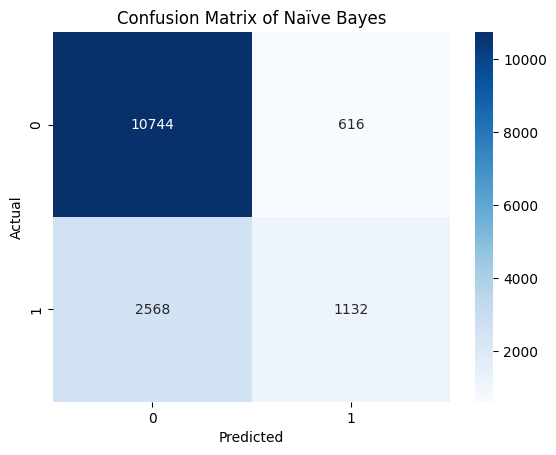

In [24]:
target_names = ["<=50K", ">50K"]

# Evaluate the model
print("Naïve Bayes Model")
nb_accuracy_score = accuracy_score(y_test_data, nb_predictions)
print("Accuracy:", nb_accuracy_score)
print("\nClassification Report:\n", classification_report(y_test_data, nb_predictions, target_names=target_names))
nb_report_dict = classification_report(y_test_data, nb_predictions, target_names=target_names, output_dict=True)

nb_confusion_matrix = confusion_matrix(y_test_data, nb_predictions)
print("\nConfusion Matrix:\n", nb_confusion_matrix)
plt.title("Confusion Matrix of Naïve Bayes")
sns.heatmap(nb_confusion_matrix, annot=True, cmap=plt.cm.Blues, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Best Naïve Bayes Model Evaluation
Accuracy: 0.7990039840637451

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.81      0.96      0.88     11360
        >50K       0.72      0.29      0.42      3700

    accuracy                           0.80     15060
   macro avg       0.77      0.63      0.65     15060
weighted avg       0.79      0.80      0.77     15060


Confusion Matrix:
 [[10947   413]
 [ 2614  1086]]


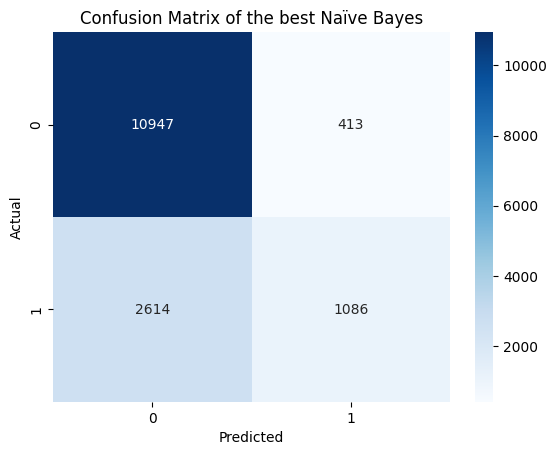

In [25]:
# Evaluate the best Naive Bayes model
best_nb = grid_nb.best_estimator_
best_nb_predictions = best_nb.predict(X_test_data)

print("\nBest Naïve Bayes Model Evaluation")
best_nb_accuracy_score = accuracy_score(y_test_data, best_nb_predictions)
print("Accuracy:", best_nb_accuracy_score)
print("\nClassification Report:\n", classification_report(y_test_data, best_nb_predictions, target_names=target_names))
best_nb_report_dict = classification_report(y_test_data, best_nb_predictions, target_names=target_names, output_dict=True)

best_nb_confusion_matrix = confusion_matrix(y_test_data, best_nb_predictions)
print("\nConfusion Matrix:\n", best_nb_confusion_matrix)
plt.title("Confusion Matrix of the best Naïve Bayes")
sns.heatmap(best_nb_confusion_matrix, annot=True, cmap=plt.cm.Blues, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### k-Nearest Neighbours Model (k-NN) Model

k-NN Model (k=5)
Accuracy: 0.7693891102257636

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.81      0.91      0.86     11360
        >50K       0.55      0.33      0.41      3700

    accuracy                           0.77     15060
   macro avg       0.68      0.62      0.63     15060
weighted avg       0.74      0.77      0.75     15060


Confusion Matrix:
 [[10381   979]
 [ 2494  1206]]


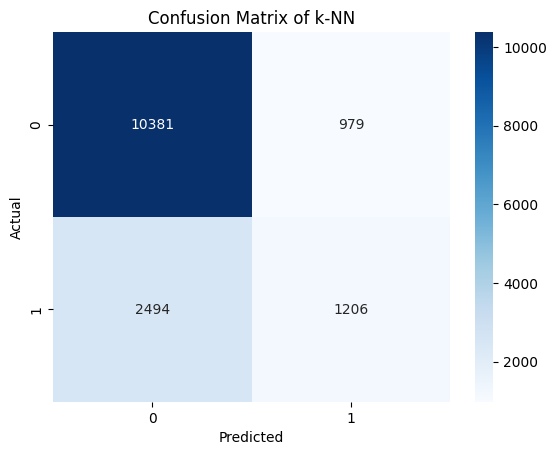

In [26]:
# Evaluate the model
print("k-NN Model (k=5)")
knn_accuracy_score = accuracy_score(y_test_data, knn_predictions)
print("Accuracy:", knn_accuracy_score)
print("\nClassification Report:\n", classification_report(y_test_data, knn_predictions, target_names=target_names))
knn_report_dict = classification_report(y_test_data, knn_predictions, target_names=target_names, output_dict=True)

knn_confusion_matrix = confusion_matrix(y_test_data, knn_predictions)
print("\nConfusion Matrix:\n", knn_confusion_matrix)
plt.title("Confusion Matrix of k-NN")
sns.heatmap(knn_confusion_matrix, annot=True, cmap=plt.cm.Blues, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Best k-NN Model (k=21) Evaluation
Accuracy: 0.7947543160690571

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.79      0.98      0.88     11360
        >50K       0.80      0.22      0.34      3700

    accuracy                           0.79     15060
   macro avg       0.80      0.60      0.61     15060
weighted avg       0.80      0.79      0.75     15060


Confusion Matrix:
 [[11159   201]
 [ 2890   810]]


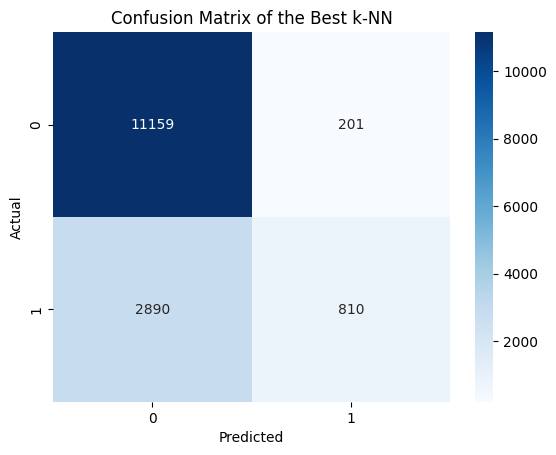

In [27]:
# Evaluate the best k-NN model
best_knn = grid_knn.best_estimator_
best_knn_predictions = best_knn.predict(X_test_data)

print("\nBest k-NN Model (k=21) Evaluation")
best_knn_accuracy_score = accuracy_score(y_test_data, best_knn_predictions)
print("Accuracy:", best_knn_accuracy_score)
print("\nClassification Report:\n", classification_report(y_test_data, best_knn_predictions, target_names=target_names))
best_knn_report_dict = classification_report(y_test_data, best_knn_predictions, target_names=target_names, output_dict=True)

best_knn_confusion_matrix = confusion_matrix(y_test_data, best_knn_predictions)
print("\nConfusion Matrix:\n", best_knn_confusion_matrix)
plt.title("Confusion Matrix of the Best k-NN")
sns.heatmap(best_knn_confusion_matrix, annot=True, cmap=plt.cm.Blues, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Comparison

In [28]:
print("Models Comparison by Metrics")
print("\nAccuracy:")
print("1. Original Naïve Bayes:", nb_accuracy_score)
print("2. Tuned Naïve Bayes:", best_nb_accuracy_score)
print("3. Original k-NN (k=5):", knn_accuracy_score)
print("4. Tuned k-NN (k=21):", best_knn_accuracy_score)

print("\nPrecision (>50K):")
print("1. Original Naïve Bayes:", nb_report_dict['>50K']['precision'])
print("2. Tuned Naïve Bayes:", best_nb_report_dict['>50K']['precision'])
print("3. Original k-NN (k=5):", knn_report_dict['>50K']['precision'])
print("4. Tuned k-NN (k=21):", best_knn_report_dict['>50K']['precision'])

print("\nPrecision Recall (>50K):")
print("1. Original Naïve Bayes:", nb_report_dict['>50K']['recall'])
print("2. Tuned Naïve Bayes:", best_nb_report_dict['>50K']['recall'])
print("3. Original k-NN (k=5):", knn_report_dict['>50K']['recall'])
print("4. Tuned k-NN (k=21):", best_knn_report_dict['>50K']['recall'])

print("\nF1-Score (>50K):")
print("1. Original Naïve Bayes:", nb_report_dict['>50K']['f1-score'])
print("2. Tuned Naïve Bayes:", best_nb_report_dict['>50K']['f1-score'])
print("3. Original k-NN (k=5):", knn_report_dict['>50K']['f1-score'])
print("4. Tuned k-NN (k=21):", best_knn_report_dict['>50K']['f1-score'])

Models Comparison by Metrics

Accuracy:
1. Original Naïve Bayes: 0.7885790172642763
2. Tuned Naïve Bayes: 0.7990039840637451
3. Original k-NN (k=5): 0.7693891102257636
4. Tuned k-NN (k=21): 0.7947543160690571

Precision (>50K):
1. Original Naïve Bayes: 0.6475972540045767
2. Tuned Naïve Bayes: 0.7244829886591061
3. Original k-NN (k=5): 0.5519450800915332
4. Tuned k-NN (k=21): 0.8011869436201781

Precision Recall (>50K):
1. Original Naïve Bayes: 0.30594594594594593
2. Tuned Naïve Bayes: 0.2935135135135135
3. Original k-NN (k=5): 0.32594594594594595
4. Tuned k-NN (k=21): 0.21891891891891893

F1-Score (>50K):
1. Original Naïve Bayes: 0.4155653450807636
2. Tuned Naïve Bayes: 0.4177726485862666
3. Original k-NN (k=5): 0.40985556499575193
4. Tuned k-NN (k=21): 0.3438760348121418
